In [15]:
from phidl import Device, Layer, LayerSet, Port
from phidl.device_layout import DeviceReference
from phidl import quickplot as qp
from phidl import set_quickplot_options

import phidl.geometry as pg
import phidl.utilities as pu
import phidl.routing as pr
import phidl.path as pp

import numpy as np
import pickle

from dataclasses import dataclass, field, replace

import copy

from typing import Tuple, Optional, Union

import itertools
import importlib

from components import utils
importlib.reload(utils)

from components import qrcsj_device
importlib.reload(qrcsj_device)

from components import default_layerset
importlib.reload(default_layerset)
from components import frame
importlib.reload(frame)
from components import feedline
importlib.reload(feedline)
from components import spiral
importlib.reload(spiral)
from components import junction
importlib.reload(junction)
from components import resistor
importlib.reload(resistor)
from components import junction_resistor
importlib.reload(junction_resistor)
from components import ground_capacitor
importlib.reload(ground_capacitor)
from components import squid_resistor
importlib.reload(squid_resistor)
from components import junction_squid_resistor
importlib.reload(junction_squid_resistor)
from components import squid
importlib.reload(squid)

from components.qrcsj_device import QRCSJDevice
from components.default_layerset import default_ls
from components.frame import Frame, FrameParams
from components.feedline import Feedline, FeedlineParams, SquarePortParams
from components.spiral import Spiral, SpiralParams
from components.junction import JJ, JJParams
from components.resistor import Resistor, ResParams
from components.junction_resistor import JJResistor, CapaParams
from components.ground_capacitor import GroundCapa, GroundCapaParams
from components.squid_resistor import SquidResistor, SquidParams
from components.junction_squid_resistor import JJSquidResistor
from components.squid import Squid
from components.utils import WritefieldParams

In [16]:
capa_spacing = 2
shadow_shift = 0.3

def connect_to_resonator(element: Union[JJResistor, SquidResistor, JJSquidResistor, Squid, JJ],
                         element_port_name: str,
                         spiral: Spiral,
                         resonator_port_name: str,
                         capa_distance: float = 0) -> None:

    resonator = spiral.device
    element_port: Port = element.device.ports[element_port_name]

    resonator_normal = resonator.ports[resonator_port_name].normal[1] - resonator.ports[resonator_port_name].normal[0]
    element_normal = element_port.normal[1] - element_port.normal[0]

    connector_parallel = [-resonator_normal[1], resonator_normal[0]]

    angle = np.round((360/(2*np.pi)) * np.arccos(np.clip(np.dot(resonator_normal,-element_normal), -1, 1)))%360

    if angle != 0:
        element.device.rotate(-angle)
        element.device.mirror()

    element.device.move(element_port, resonator.ports[resonator_port_name])
    element.device.move((capa_distance) * resonator_normal)
    element.device.movex(origin=element_port.x, destination=resonator.ports['out'].x)
    element.device.movex(element_port.width/2)



def add_ground_capacitor(reference: DeviceReference,
                         port_name: str,
                         feedline: Feedline,
                         length: float = 500,
                         width: float = 3,
                         capa_distance: float = 0,
                         layer: Layer = default_ls['routing']) -> None:
    
    element_port: Port = reference.ports[port_name]
    element_normal = element_port.normal[1] - element_port.normal[0]

    ground_capacitor = Device('Ground capacitor')
    ground_capacitor << pg.rectangle(size=(width, length), layer=layer)

    if length > 0:
        ground_capacitor.add_port(name='capa in', 
                              midpoint=(0, length - element_port.width/2),
                              width=element_port.width,
                              orientation=180)
    else:
         ground_capacitor.add_port(name='capa in', 
                              midpoint=(0, length + element_port.width/2),
                              width=element_port.width,
                              orientation=180)
    
    
    ground_capacitor_ref = feedline.device << ground_capacitor
    ground_capacitor_ref.connect('capa in', element_port)
    ground_capacitor_ref.move(element_normal * capa_distance)


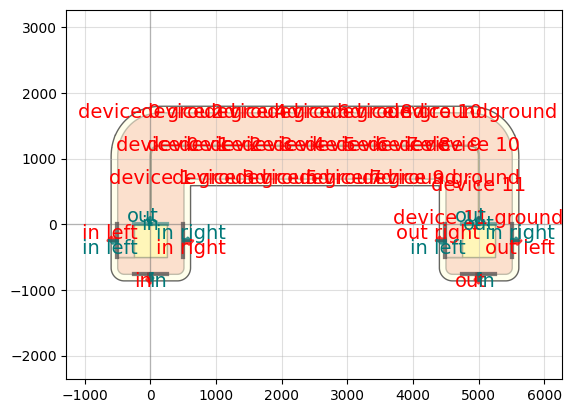

In [17]:
feedline_bot = Feedline()


feedline_points = [(0, 0), (0, 1200), (5000, 1200), (5000, 0)]
# device_points = [(x, 1200) for x in np.linspace(start=100, stop=4900, num=9)]

device_points = [(x, 1200) for x in np.linspace(start=100, stop=4900, num=11)] + [(5000, 600)]
device_orientations = [90, -90, 90, -90, 90, -90, 90, -90, 90, -90, 90] + [0]
ground_points = [(device_point[0], device_point[1] + (505*(-1)**i)) for i, device_point in enumerate(device_points)] + [(5505, 600)]
    
    
feedline_bot.generate_feedline(FeedlineParams(feedline_points=feedline_points, 
                                              device_points=device_points, 
                                              device_ground_points=ground_points,
                                              device_orientations=device_orientations))


qp(feedline_bot.device)

In [18]:
QuantumCircuits = []

writefield_params = WritefieldParams()


# 11 Squids with different resistors
squid_params = SquidParams(jj_width=0.2, bridge_width=0.3, junction_layer=default_ls['ebeam_large_junctions'])

list_capa_params = [CapaParams(no_resistor=True, ebeam_capa=True)] + [CapaParams(ebeam_capa=True)]*10


list_res_params = []

list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=5, segment_length=25)) #10kOhm (removed later on)

list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=48, segment_length=6, spacing=1.3, highdose_layer=default_ls['ebeam'], ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) ### 250Ohm
list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=32, segment_length=8, spacing=1.9, ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) ### 500Ohm
list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=32, segment_length=12, spacing=1.9, ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) ### 750Ohm


#1kOhm
list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=20, segment_length=10, spacing=3, ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) 


#1.25kOhm
# list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=20, segment_length=12.5, spacing=1, ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) 


#1.5kOhm
list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=20, segment_length=15, spacing=3, ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) 


#2kOhm
# list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=20, segment_length=20, spacing=2, ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) 


#3kOhm
list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=20, segment_length=30, spacing=3, ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) 

#5kOhm
list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=10, segment_length=25, spacing=3, ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) 

list_res_params.append(ResParams(small_resistor=True, connectors=False, num_segments=5, segment_length=25, ebeam_layer=default_ls['ebeam_low'], undercut_layer=default_ls['undercut_low'])) #10kOhm
list_res_params.append(ResParams(small_resistor=False, connectors=True, spacing=6, num_segments=2, segment_length=25, connector_height=2)) #100kOhm
list_res_params.append(ResParams(small_resistor=False, connectors=True, spacing=4, num_segments=10, segment_length=50, connector_height=2)) #1MOhm



for i,(res_param,capa_param) in enumerate(zip(list_res_params, list_capa_params)):
    squid_resistor = SquidResistor()
    if not i%2:
        res_param.mirrored_x_axis = True

    try:
        squid_resistor.generate_squid_resistor(res_param, squid_params, capa_param, writefield_params)
    except:
        print(i)

    if i == 0:
        squid_resistor.device.remove(squid_resistor.shunt_resistor)

    if i%2:
        squid_resistor.device.mirror()



    QuantumCircuits.append(squid_resistor)




failed offsetting undercut


In [19]:
# make spirals
Ns = np.concatenate([np.round(np.linspace(15.48, 16.1, 11), 2), [16]])

Ns_multiplex = [[Ns[((i)*4)+j] for i in range(3)] for j in range(4)]
Ns_multiplex = [N for Ns in Ns_multiplex for N in Ns]

print(Ns)
print(Ns_multiplex)

spirals: list[Spiral] = []
all_devices: list[QRCSJDevice] = []

for i,N in enumerate(Ns_multiplex[:-1]):
    spiral = Spiral()
    spiral.generate_spiral(SpiralParams(N=N, connector_shift=pg.extract(QuantumCircuits[i].device, layers=[default_ls['ebeam']]).ysize/2))

    spirals.append(spiral)

    device = QRCSJDevice()
    device.assembled_device = Device()
    all_devices.append(device)

    device.spiral = spiral
    spiral_ref = device.assembled_device << spiral.device
    device.assembled_device.add_port(spiral_ref.ports['in'])
    device.assembled_device.add_port(spiral_ref.ports['out'])



    # capacitance on the other side for this device
    if not i%2:


        try:
            connect_to_resonator(QuantumCircuits[i], 'capa top', spiral, 'capa right')
        except:
            connect_to_resonator(QuantumCircuits[i], 'top', spiral, 'capa right')

        try:
            device.assembled_device.add_port(name='capa out', port=QuantumCircuits[i].device.ports['capa bot'])
        except:
            device.assembled_device.add_port(name='capa out', port=QuantumCircuits[i].device.ports['bot'])
        
    # capacitance on "standard" side
    else:
        try:
            connect_to_resonator(QuantumCircuits[i], 'capa bot', spiral, 'capa right')
        except:
            connect_to_resonator(QuantumCircuits[i], 'bot', spiral, 'capa right')

        try:
            device.assembled_device.add_port(name='capa out', port=QuantumCircuits[i].device.ports['capa top'])
        except:
            device.assembled_device.add_port(name='capa out', port=QuantumCircuits[i].device.ports['top'])


  

    device.assembled_device << QuantumCircuits[i].device
    
    device.qubit = squid_resistor

    


spiral = Spiral()
spiral.generate_spiral(SpiralParams(N=Ns_multiplex[-1]))
spirals.append(spiral)





print([np.round(spiral.get_resonance_frequency()) for spiral in spirals])

[15.48 15.54 15.6  15.67 15.73 15.79 15.85 15.91 15.98 16.04 16.1  16.  ]
[15.48, 15.73, 15.98, 15.54, 15.79, 16.04, 15.6, 15.85, 16.1, 15.67, 15.91, 16.0]
[8681287997.0, 8385251088.0, 8102321207.0, 8609000825.0, 8316182250.0, 8036282456.0, 8537503993.0, 8247857269.0, 7970944448.0, 8455074621.0, 8180265503.0, 8080229813.0]


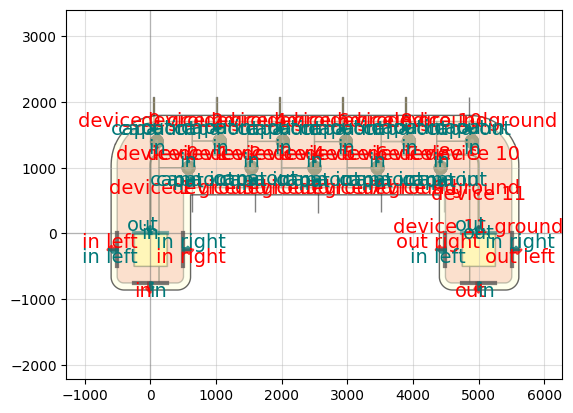

In [20]:
coupling_distance = 100
all_device_refs: list[DeviceReference] = []

shift = 4.3


for i,device in enumerate(all_devices):
    all_device_refs.append(feedline_bot.device << device.assembled_device)

    all_device_refs[-1].connect('in', feedline_bot.device.ports[f'device {i}'])

    normal = all_device_refs[-1].ports['in'].normal[0] - all_device_refs[-1].ports['in'].normal[1]
    all_device_refs[-1].move(normal * coupling_distance)

  
    add_ground_capacitor(all_device_refs[-1], 'capa out', feedline_bot)
 
        




feedline_bot.correct_optical_layer()
    
qp(feedline_bot.device)

In [21]:
feedline_bot.device.write_gds('Feedline_Bot.gds')

with open('feedline_bot.pkl', 'wb') as f:
    pickle.dump(feedline_bot, f)